In [1]:
import torch
from src.model import ImagePairEncoder, TransformDecoder, TransformDecoderRope, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms

%load_ext autoreload
%autoreload 2

### Testing Model

In [ ]:
config = OmegaConf.load('configs/train_config_007.yaml')

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [3]:
model = ImageTransformPredictor(config.model)

Loaded pretrained weights for efficientnet-b3


In [20]:
checkpoint_path = 'checkpoints/itp_007/checkpoint_epoch_14.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

ready


['grayscale', 'rotate_270', 'crop', 'compression', 'color_jitter', 'horizontal_flip', 'vertical_flip']


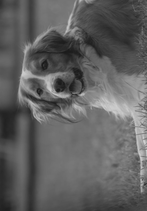

In [30]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1)
print(sequence_1)
transformed_image_1

In [28]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['grayscale', 'noise_adding', 'rotate_90', 'horizontal_flip', 'crop']
Target: ['rotate_270', 'grayscale', 'color_jitter', 'crop', 'vertical_flip', 'noise_adding']


### New Decoder

In [2]:
config = OmegaConf.load('configs/train_config_007.yaml')

In [3]:
encoder = ImagePairEncoder(config.model.encoder)

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

encoder.eval()
with torch.no_grad():
    test_images1 = torch.randn(1, 3, 224, 224)
    test_images2 = torch.randn(1, 3, 224, 224)
    embs = encoder(test_images1, test_images2)
embs.shape

Loaded pretrained weights for efficientnet-b3


torch.Size([1, 512])

In [8]:
decoder = TransformDecoderRope(config.model.decoder)

decoder.eval()
with torch.no_grad():
    seq = decoder.generate(embs, max_new_tokens=14, do_sample=True)
seq.shape
print(seq)

tensor([[ 1, 11, 11, 13, 11,  6,  7,  7,  7,  7,  2,  0,  0,  0,  0]])
